In [1]:
# 🔹 Step 1: Import necessary libraries
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# 🔹 Step 2: Load and prepare the dataset
df = pd.read_csv(r"C:\Users\Karla Legarde\Documents\DATA ANALYTICS + MANAGEMENT & LEADERSHIP\DATA ANALYTICS\Winter 2025\Data 406 Capstone\UA2022_2024.csv")
df.head()

,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,...,DIVERTED,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRCRAFT_OWNER,AIRCRAFT_SEATS
0,1/1/2022 12:00:00 AM,UA,1004.0,N75432,1004.0,12892,LAX,"Los Angeles, CA",12402,ITO,...,0.0,2449.0,10,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,191
1,1/1/2022 12:00:00 AM,UA,1005.0,N831UA,1005.0,14492,RDU,"Raleigh/Durham, NC",11292,DEN,...,0.0,1436.0,6,13.0,0.0,91.0,0.0,118.0,UNITED AIRLINES INC ...,179
2,1/1/2022 12:00:00 AM,UA,1006.0,N27526,1006.0,14771,SFO,"San Francisco, CA",14747,SEA,...,0.0,679.0,3,17.0,0.0,0.0,0.0,26.0,WILMINGTON TRUST CO TRUSTEE ...,48
3,1/1/2022 12:00:00 AM,UA,1007.0,N17752,1007.0,14107,PHX,"Phoenix, AZ",12266,IAH,...,0.0,1009.0,5,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,149
4,1/1/2022 12:00:00 AM,UA,1008.0,N486UA,1008.0,11618,EWR,"Newark, NJ",14492,RDU,...,0.0,416.0,2,126.0,0.0,0.0,0.0,0.0,UNITED AIRLINES INC ...,200


In [3]:
# 🔹 Step 3: Convert date & classify delay duration
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["FL_FIRST_DAY"] = df["FL_DATE"].dt.to_period("M").dt.to_timestamp()

C:\Users\Karla Legarde\AppData\Local\Temp\ipykernel_13556\215127883.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


In [4]:
# Risk Categories
def categorize_delay(delay):
    if delay <= 60:
        return "Low Delay"
    elif 60 < delay < 360:
        return "Moderate Delay"
    else:
        return "High Delay"

df["Delay_Category"] = df["ARR_DELAY_NEW"].apply(categorize_delay)
df

,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,...,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRCRAFT_OWNER,AIRCRAFT_SEATS,FL_FIRST_DAY,Delay_Category
0,2022-01-01,UA,1004.0,N75432,1004.0,12892,LAX,"Los Angeles, CA",12402,ITO,...,10,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,191,2022-01-01,Low Delay
1,2022-01-01,UA,1005.0,N831UA,1005.0,14492,RDU,"Raleigh/Durham, NC",11292,DEN,...,6,13.0,0.0,91.0,0.0,118.0,UNITED AIRLINES INC ...,179,2022-01-01,Moderate Delay
2,2022-01-01,UA,1006.0,N27526,1006.0,14771,SFO,"San Francisco, CA",14747,SEA,...,3,17.0,0.0,0.0,0.0,26.0,WILMINGTON TRUST CO TRUSTEE ...,48,2022-01-01,Low Delay
3,2022-01-01,UA,1007.0,N17752,1007.0,14107,PHX,"Phoenix, AZ",12266,IAH,...,5,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,149,2022-01-01,Low Delay
4,2022-01-01,UA,1008.0,N486UA,1008.0,11618,EWR,"Newark, NJ",14492,RDU,...,2,126.0,0.0,0.0,0.0,0.0,UNITED AIRLINES INC ...,200,2022-01-01,Moderate Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3834948,2024-12-31,UA,793.0,N801UA,793.0,11292,DEN,"Denver, CO",14831,SJC,...,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,179,2024-12-01,Low Delay
3834949,2024-12-31,UA,794.0,N78004,794.0,11618,EWR,"Newark, NJ",14771,SFO,...,11,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,400,2024-12-01,Low Delay
3834950,2024-12-31,UA,795.0,N67501,795.0,12266,IAH,"Houston, TX",13930,ORD,...,4,NaN,NaN,NaN,NaN,NaN,UNITED AIRLINES INC ...,48,2024-12-01,Low Delay
3834951,2024-12-31,UA,796.0,N27266,796.0,12266,IAH,"Houston, TX",11697,FLL,...,4,NaN,NaN,NaN,NaN,NaN,WILMINGTON TRUST CO TRUSTEE ...,175,2024-12-01,Low Delay


In [5]:
# 🔹 Step 4: Group by month and risk category, then sum AIRCRAFT_SEATS
monthly_seats = df.groupby(["FL_FIRST_DAY", "Delay_Category"])["AIRCRAFT_SEATS"].sum().unstack().fillna(0)

In [6]:
monthly_seats

Delay_Category,High Delay,Low Delay,Moderate Delay
FL_FIRST_DAY,,,
2022-01-01,33574,10475821,857237
2022-02-01,32247,10575082,660571
2022-03-01,42926,12202757,854753
2022-04-01,42065,11770819,760828
2022-05-01,55980,12231254,986536
2022-06-01,56270,11845819,1032726
2022-07-01,45030,12376121,1065358
2022-08-01,54934,12105450,968817
2022-09-01,22817,12156494,490952


In [7]:
# 🔹 Step 5: Apply load factor to estimate actual passengers onboard
load_factor = 0.8353
monthly_passengers = np.ceil(monthly_seats * load_factor).astype(int)


In [8]:
monthly_passengers

Delay_Category,High Delay,Low Delay,Moderate Delay
FL_FIRST_DAY,,,
2022-01-01,28045,8750454,716051
2022-02-01,26936,8833366,551775
2022-03-01,35857,10192963,713976
2022-04-01,35137,9832166,635520
2022-05-01,46761,10216767,824054
2022-06-01,47003,9894813,862637
2022-07-01,37614,10337774,889894
2022-08-01,45887,10111683,809253
2022-09-01,19060,10154320,410093


In [9]:
# 🔹 Step 6: Forecast monthly passengers using SARIMA
passenger_forecast = {}

for category in monthly_passengers.columns:
    series = monthly_passengers[category]
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit(disp=False)
    forecast = model_fit.forecast(steps=12)
    passenger_forecast[category] = forecast


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\b

In [10]:
# Build forecast DataFrame
forecast_passenger_df = pd.DataFrame(passenger_forecast)
forecast_passenger_df.index = pd.date_range(start="2025-01-01", periods=12, freq="MS")
forecast_passenger_df = forecast_passenger_df.round().astype(int)
forecast_passenger_df["Month"] = forecast_passenger_df.index


In [11]:
# Preview
forecast_passenger_df

,High Delay,Low Delay,Moderate Delay,Month
2025-01-01,37189,11774744,951652,2025-01-01
2025-02-01,31099,11949498,664297,2025-02-01
2025-03-01,32058,13153925,795698,2025-03-01
2025-04-01,48213,12716858,854348,2025-04-01
2025-05-01,43084,12490257,1104361,2025-05-01
2025-06-01,69597,12759519,1288803,2025-06-01
2025-07-01,64811,12474259,1564215,2025-07-01
2025-08-01,43465,13031829,945080,2025-08-01
2025-09-01,36955,13628477,645041,2025-09-01
2025-10-01,27647,14468595,508502,2025-10-01


In [12]:
# 🔹 Step 7: Combine with historical for plotting
# Ensure datetime index for historical data
monthly_passengers.index = pd.to_datetime(monthly_passengers.index)
forecast_passenger_df.index = pd.to_datetime(forecast_passenger_df.index)

# Merge both for plotting
combined_passenger_df = pd.concat([
    monthly_passengers,
    forecast_passenger_df.drop(columns="Month")
])
combined_passenger_df.index.name = "FL_FIRST_DAY"
combined_passenger_df.reset_index(inplace=True)

# Make sure the date column is datetime type
combined_passenger_df["FL_FIRST_DAY"] = pd.to_datetime(combined_passenger_df["FL_FIRST_DAY"])

Unique years in combined_passenger_df: [2022 2023 2024 2025]


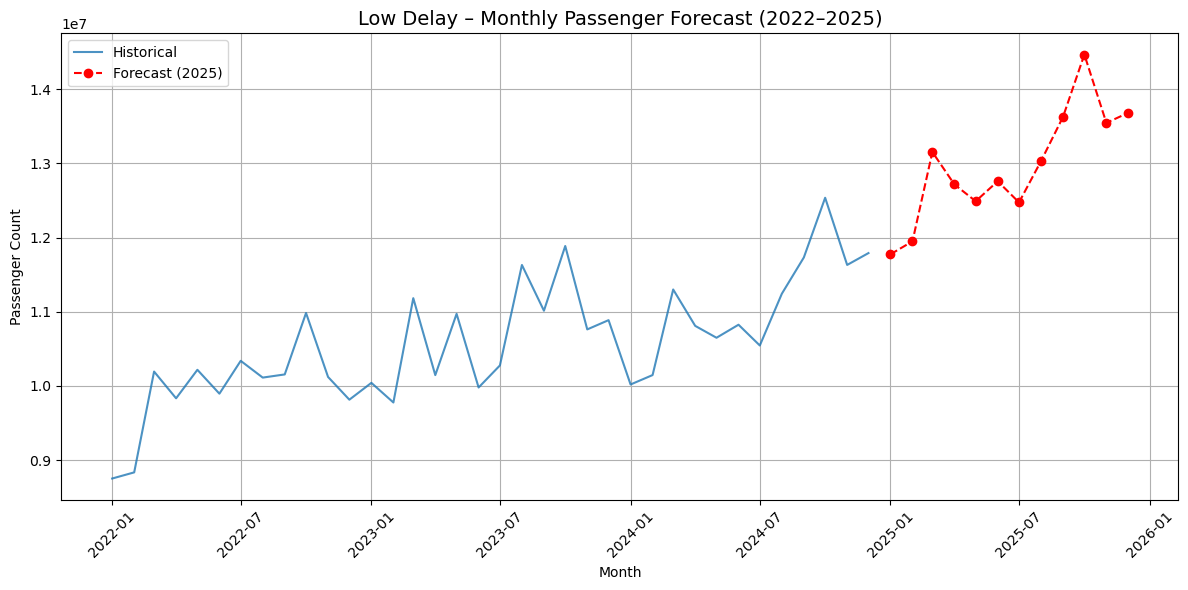

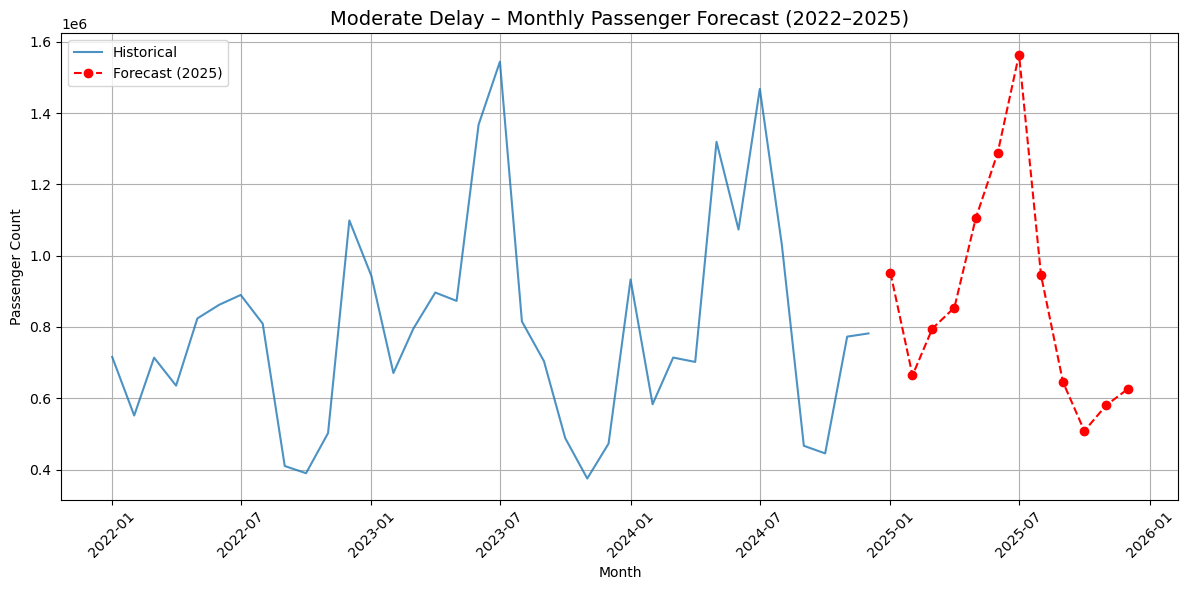

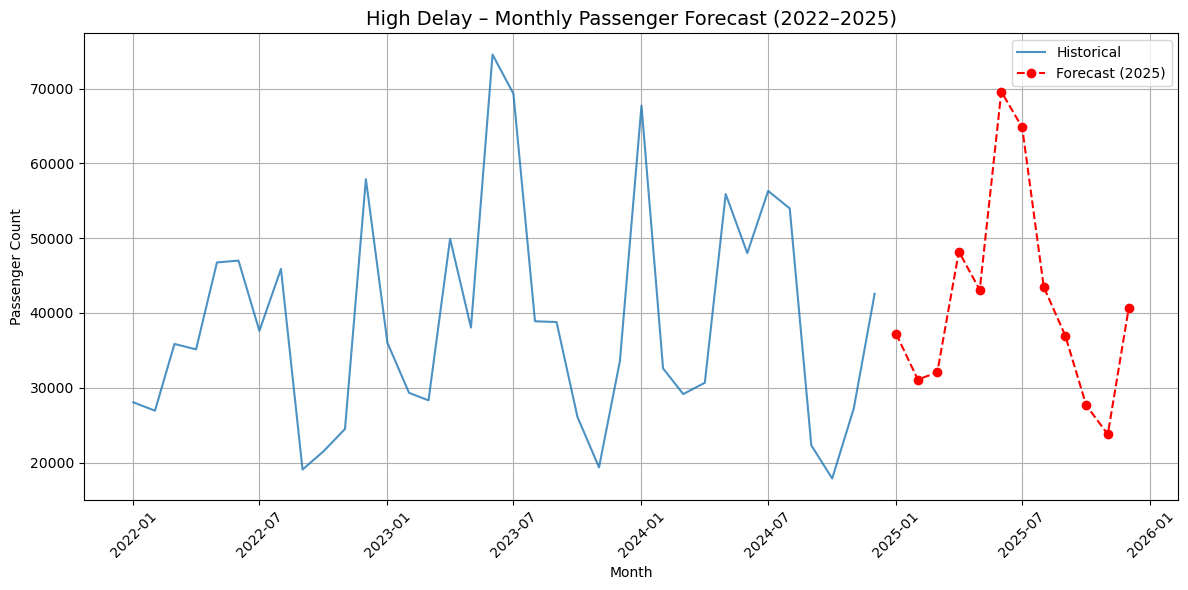

In [13]:
# 🔹 Step 8: Plot per category
# Make sure index is datetime and consistent
monthly_passengers.index = pd.to_datetime(monthly_passengers.index)
forecast_passenger_df.index = pd.to_datetime(forecast_passenger_df.index)

# Combine historical and forecast data
combined_passenger_df = pd.concat([
    monthly_passengers,
    forecast_passenger_df.drop(columns="Month")
])
combined_passenger_df.index.name = "FL_FIRST_DAY"

# Reset index and explicitly convert column to datetime
combined_passenger_df = combined_passenger_df.reset_index()
combined_passenger_df["FL_FIRST_DAY"] = pd.to_datetime(combined_passenger_df["FL_FIRST_DAY"])

# DEBUG: Print year values to verify
print("Unique years in combined_passenger_df:", combined_passenger_df["FL_FIRST_DAY"].dt.year.unique())

# Plot each delay category
delay_categories = ["Low Delay", "Moderate Delay", "High Delay"]

for category in delay_categories:
    plt.figure(figsize=(12, 6))

    # Historical
    historical = combined_passenger_df[combined_passenger_df["FL_FIRST_DAY"].dt.year < 2025]
    plt.plot(historical["FL_FIRST_DAY"], historical[category], label="Historical", alpha=0.8)

    # Forecast
    forecast = combined_passenger_df[combined_passenger_df["FL_FIRST_DAY"].dt.year == 2025]
    plt.plot(forecast["FL_FIRST_DAY"], forecast[category], linestyle='--', marker='o',
             color='red', label="Forecast (2025)")

    plt.title(f"{category} – Monthly Passenger Forecast (2022–2025)", fontsize=14)
    plt.xlabel("Month")
    plt.ylabel("Passenger Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# Save forecasted passengers for 2025 to CSV
forecast_passenger_df.to_csv("forecasted_passengers_2025.csv", index=False)


SAVE TO LONG FORMAT

In [15]:
# - monthly_passengers: your 2022–2024 historical passengers (by risk category)
# - forecast_passenger_df: your SARIMA forecasted passengers for 2025

# Step 1: Prepare for merging
monthly_passengers.index = pd.to_datetime(monthly_passengers.index)
forecast_passenger_df.index = pd.to_datetime(forecast_passenger_df.index)

# Step 2: Reset index and add 'Type' labels
hist_df = monthly_passengers.copy()
hist_df["FL_FIRST_DAY"] = hist_df.index
hist_df["Type"] = "Historical"

forecast_df = forecast_passenger_df.copy()
forecast_df["FL_FIRST_DAY"] = forecast_df.index
forecast_df["Type"] = "Forecast"
forecast_df = forecast_df.drop(columns="Month", errors="ignore")  # In case "Month" is still there

# Step 3: Combine both
combined_df = pd.concat([hist_df, forecast_df], ignore_index=True)

# Step 4: Convert to long format
df_long_passengers = combined_df.melt(
    id_vars=["FL_FIRST_DAY", "Type"],
    value_vars=["Low Delay", "Moderate Delay", "High Delay"],
    var_name="Risk_Category",
    value_name="Passenger_Count"
)

# Optional: Save to CSV
df_long_passengers.to_csv("passenger_forecast.csv", index=False)

# Preview result
df_long_passengers

,FL_FIRST_DAY,Type,Risk_Category,Passenger_Count
0,2022-01-01,Historical,Low Delay,8750454
1,2022-02-01,Historical,Low Delay,8833366
2,2022-03-01,Historical,Low Delay,10192963
3,2022-04-01,Historical,Low Delay,9832166
4,2022-05-01,Historical,Low Delay,10216767
...,...,...,...,...
139,2025-08-01,Forecast,High Delay,43465
140,2025-09-01,Forecast,High Delay,36955
141,2025-10-01,Forecast,High Delay,27647
142,2025-11-01,Forecast,High Delay,23773
